# Successor head emergence preview — Pythia 70m/160m/410m

**Phase 1.4 deliverable (iii).** 18-cell exploration sweep: Pythia `{70m, 160m, 410m}` × `{0, 1k, 3k, 8k, 25k, 143k}`. Per cell: re-build prompts under that model's tokenizer (GPT-NeoX BPE, first-token mappings logged), run the §SU-1b lift-form successor screen, save per-head `lift = mean over 4 categories of (real − null)`. The same locked **τ_lift = 0.13496** (§SU-tau, calibrated from GPT-2 small validation) applies uniformly across all 18 cells.

**Locked threshold (HYPOTHESIS.md §SU-tau):**
- τ_lift = 0.13496 (95th percentile of pooled per-head lifts from the GPT-2 small validation screen).

**Per Q9-(b) sweep gating policy**, this runs unconditionally — the Pythia-410M anchor (deliverable ii) result documents either way. The anchor passed both §SU-5 gates (numerical: 2 heads clear τ_lift on Pythia-410M @ step143000; qualitative: top candidate L22H6 has positive lift across all 4 categories), so the emergence figures here are interpretable as *the* successor emergence trajectory, not as Path-C-style negative-result documentation.

**This is exploration, not the pre-registered Phase 2 sweep.** Phase 2 will use 40 checkpoints per size and bootstrap CIs.

**The 3-motif H1-C bookend.** Phases 1.0/1.3/1.4 have all produced 18-cell emergence-preview sweeps on the same grid for induction, S-inhibition, and now successor. This notebook lays them side-by-side and tests the registered ordering **induction → successor → S-inhibition** — the load-bearing claim of H1-C.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long

SIZES = ['70m', '160m', '410m']
STEPS = [0, 1000, 3000, 8000, 25000, 143000]
TAU_LIFT = 0.13496
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green'}

## Load sweep data

Long-format parquet from `_run_successor_sweep.py` with motif `successor_lift_dla`. Per-cell raw npz holds the (layer, head) tensors and per-category breakdowns for visualization.

In [2]:
df = read_long(REPO / 'data' / 'exploration' / 'successor_emergence_preview.parquet')
print(f'Total rows: {len(df):,}')
print(f'Motifs: {df.motif.unique().tolist()}')
print(f'Sizes: {sorted(df["size"].unique().tolist())}')
print(f'Steps: {sorted(df.step.unique().tolist())}')
print(f'\nHeads per (size, step) cell:')
print(df.groupby(['size', 'step']).size().unstack().to_string())

Total rows: 3,456
Motifs: ['successor_lift_dla']
Sizes: ['160m', '410m', '70m']
Steps: [0, 1000, 3000, 8000, 25000, 143000]

Heads per (size, step) cell:
step  0       1000    3000    8000    25000   143000
size                                                
160m     144     144     144     144     144     144
410m     384     384     384     384     384     384
70m       48      48      48      48      48      48


## Per-cell summary

For each (size, step), count of heads above τ_lift; max lift; (layer, head) of the top candidate.

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_strict = int((scores >= TAU_LIFT).sum())
    max_idx = int(np.argmax(scores))
    top_row = grp.iloc[max_idx]
    summary_rows.append(dict(
        size=size, step=step,
        n_strict=n_strict,
        max_lift=float(scores.max()),
        top_layer=int(top_row['layer']), top_head=int(top_row['head']),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_strict  max_lift  top_layer  top_head
 70m      0         0  0.005831          2         0
 70m   1000         0  0.016962          5         2
 70m   3000         0  0.028421          2         7
 70m   8000         1  0.144549          5         7
 70m  25000         0  0.072829          5         7
 70m 143000         2  0.164782          4         0
160m      0         0  0.003248          6         1
160m   1000         0  0.005208         11         4
160m   3000         0  0.022913          3         8
160m   8000         1  0.268225         10         1
160m  25000         3  0.840624         10         1
160m 143000         3  0.445783          9        10
410m      0         0  0.001396         13        15
410m   1000         0  0.004471         20         1
410m   3000         0  0.075197         12         8
410m   8000         1  0.153664         12         8
410m  25000         6  0.606055         22         6
410m 143000         2  0.289886         22    

## Headline emergence count plot

Per Pythia size, count of heads clearing τ_lift over training. If successor heads emerge later than induction (per H1-C), expect the count to start at 0 and rise as training progresses.

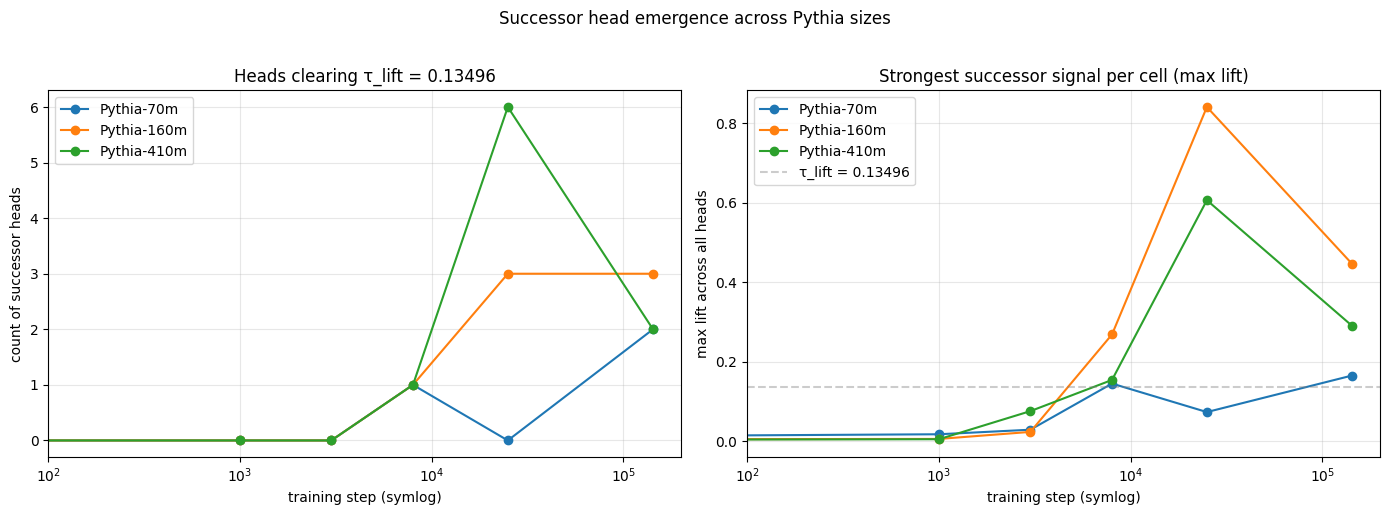

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, title) in zip(
    axes,
    [
        ('n_strict', f'Heads clearing τ_lift = {TAU_LIFT}'),
        ('max_lift', 'Strongest successor signal per cell (max lift)'),
    ],
):
    for size in SIZES:
        sub = summary[summary['size'] == size]
        ax.plot(sub['step'], sub[col], marker='o',
                color=SIZE_COLOR[size], label=f'Pythia-{size}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(100, 200000)
    ax.set_xlabel('training step (symlog)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('count of successor heads')
axes[1].set_ylabel('max lift across all heads')
axes[1].axhline(TAU_LIFT, color='gray', linestyle='--', alpha=0.4,
                label=f'τ_lift = {TAU_LIFT}')
axes[1].legend()
fig.suptitle('Successor head emergence across Pythia sizes', y=1.02)
plt.tight_layout()
plt.show()

## Successor lift across (layer, head) over training

Per-cell heatmap grid mirroring the s_inhibition emergence convention: viridis colormap (since lift > 0 is the successor signal direction; negative lift is anti-successor and not load-bearing here). Bright cells indicate emerging successor heads; the per-cell layer of the bright cells answers *where* successor lives in each model size.

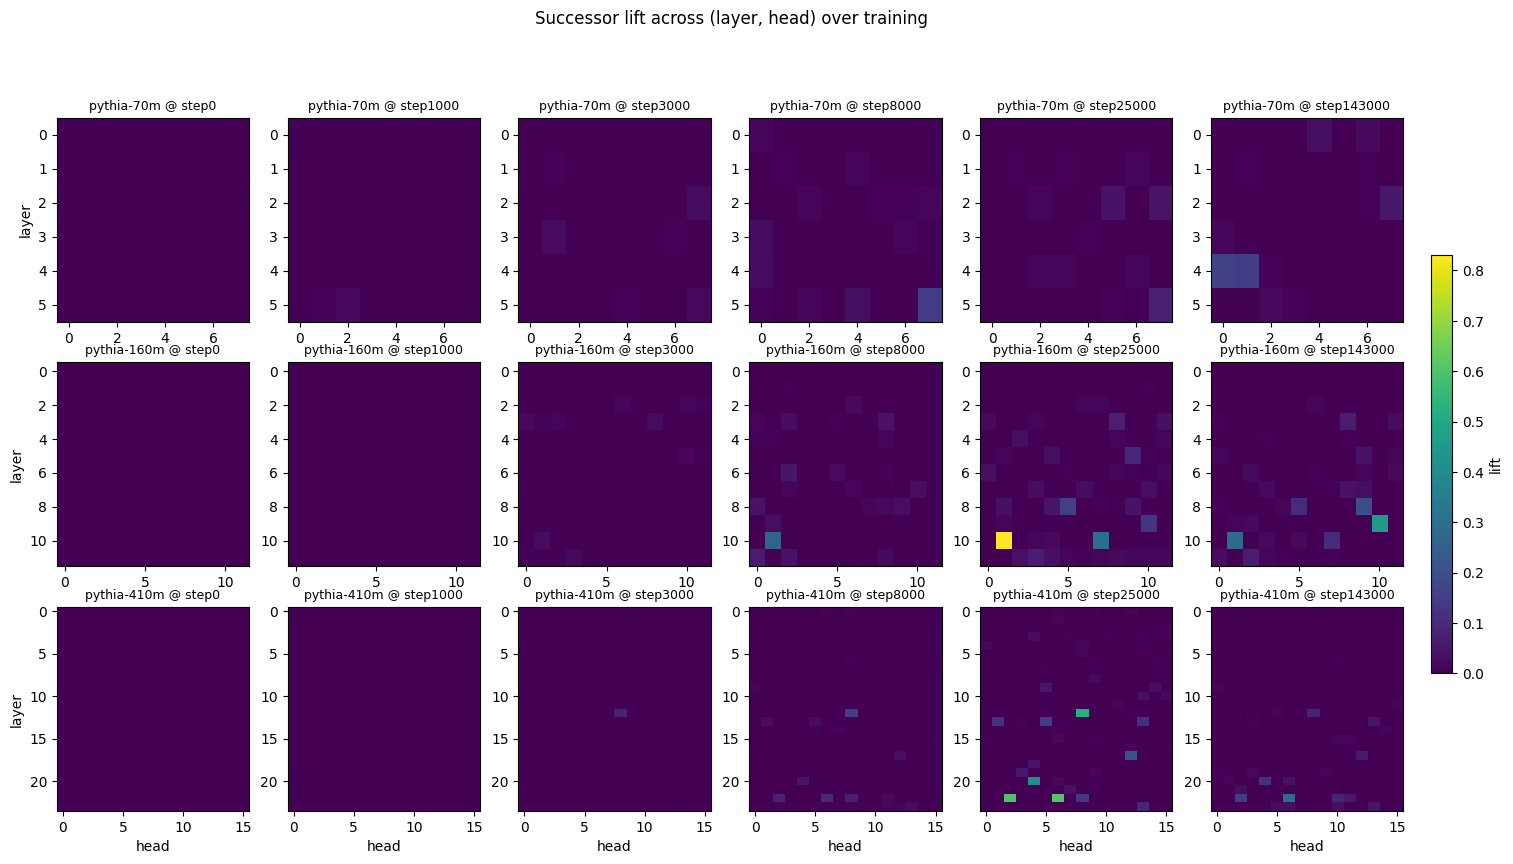

In [5]:
raw_npz = np.load(
    REPO / 'data' / 'exploration' / 'successor_emergence_per_cell.npz'
)
abs_max = float(np.abs(df['score']).max())
fig, axes = plt.subplots(
    nrows=len(SIZES), ncols=len(STEPS),
    figsize=(3 * len(STEPS), 3 * len(SIZES)),
)
for row, size in enumerate(SIZES):
    for col, step in enumerate(STEPS):
        ax = axes[row][col]
        key = f'lift__{size}_step{step}'
        if key not in raw_npz.files:
            ax.set_visible(False)
            continue
        grid = raw_npz[key]
        n_layers, n_heads = grid.shape
        im = ax.imshow(grid, vmin=0, vmax=abs_max - 0.01,
                       cmap='viridis', aspect='auto')
        ax.set_title(f'pythia-{size} @ step{step}', fontsize=9)
        if col == 0:
            ax.set_ylabel('layer')
        if row == len(SIZES) - 1:
            ax.set_xlabel('head')
fig.suptitle('Successor lift across (layer, head) over training', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='lift')
plt.show()

## H1-C 3-way ordering — induction vs successor vs S-inhibition

The registered hypothesis predicts **induction → successor → S-inhibition** in emergence order across all three Pythia sizes. All three motifs now have 18-cell preview sweeps on the same grid; this is the 3-motif comparison that bookends Phase 1.

Per Pythia size, plot count-vs-step for each motif:
- **Induction**: count of heads with prefix-matching > 0.3 (locked threshold).
- **Successor**: count of heads with lift ≥ τ_lift = 0.13496 (this notebook).
- **S-inhibition**: count of heads with Δ_h ≥ τ_strict = 0.0372 (Phase 1.3 lock).

If H1-C holds, induction's count rises first, then successor, then S-inhibition.

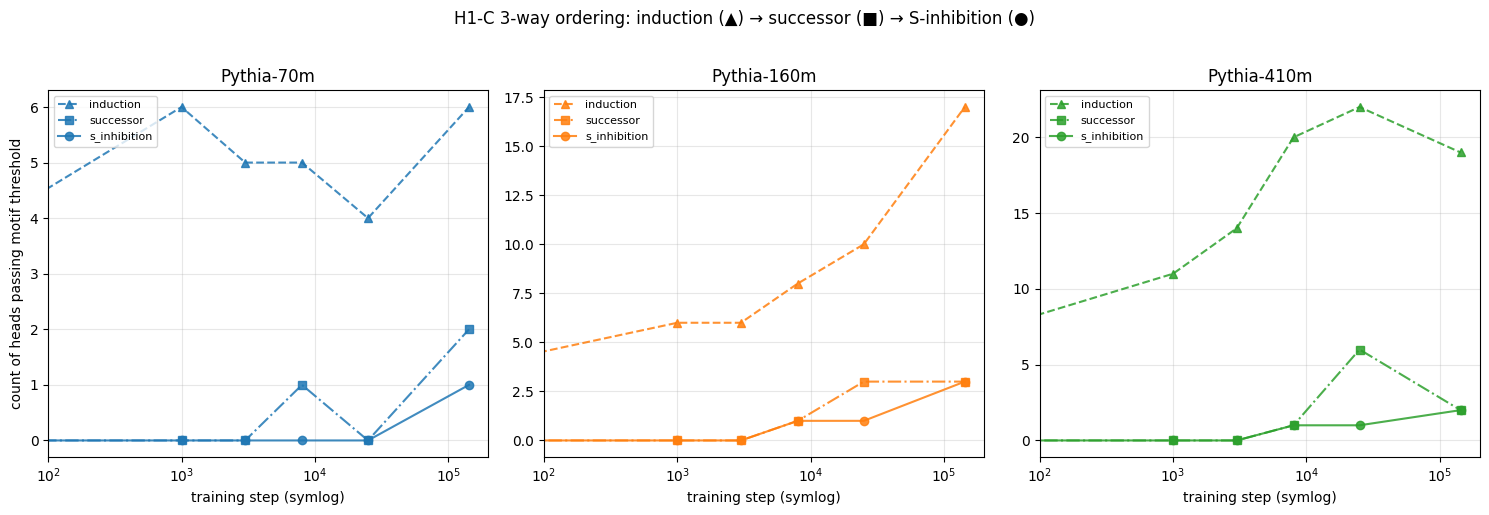

In [6]:
ind_path = REPO / 'data' / 'exploration' / 'induction_emergence_preview.parquet'
si_path = REPO / 'data' / 'exploration' / 's_inhibition_emergence_preview.parquet'
TAU_INDUCTION = 0.3
TAU_S_INHIBITION = 0.0372

rows = []
for size in SIZES:
    for step in STEPS:
        # successor
        sub = df[(df['size'] == size) & (df['step'] == step)]
        rows.append(dict(size=size, step=step, motif='successor',
                         n_passing=int((sub['score'] >= TAU_LIFT).sum())))
if ind_path.exists():
    df_ind = read_long(ind_path)
    for size in SIZES:
        for step in STEPS:
            sub = df_ind[(df_ind['size'] == size) & (df_ind['step'] == step)]
            if not sub.empty:
                rows.append(dict(size=size, step=step, motif='induction',
                                 n_passing=int((sub['score'] > TAU_INDUCTION).sum())))
if si_path.exists():
    df_si = read_long(si_path)
    for size in SIZES:
        for step in STEPS:
            sub = df_si[(df_si['size'] == size) & (df_si['step'] == step)]
            if not sub.empty:
                rows.append(dict(size=size, step=step, motif='s_inhibition',
                                 n_passing=int((sub['score'] >= TAU_S_INHIBITION).sum())))
comparison = pd.DataFrame(rows)

MOTIF_MARKER = {'induction': '^', 'successor': 's', 's_inhibition': 'o'}
MOTIF_LINESTYLE = {'induction': '--', 'successor': '-.', 's_inhibition': '-'}

fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 5), sharey=False)
for ax, size in zip(axes, SIZES):
    for motif in ['induction', 'successor', 's_inhibition']:
        sub = comparison[(comparison['size'] == size) & (comparison['motif'] == motif)]
        if sub.empty:
            continue
        sub = sub.sort_values('step')
        ax.plot(sub['step'], sub['n_passing'],
                marker=MOTIF_MARKER[motif],
                linestyle=MOTIF_LINESTYLE[motif],
                color=SIZE_COLOR[size],
                label=motif, alpha=0.85)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(100, 200000)
    ax.set_xlabel('training step (symlog)')
    if size == SIZES[0]:
        ax.set_ylabel('count of heads passing motif threshold')
    ax.set_title(f'Pythia-{size}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
fig.suptitle('H1-C 3-way ordering: induction (▲) → successor (■) → S-inhibition (●)', y=1.02)
plt.tight_layout()
plt.show()

## First-emergence step per motif and size

For each (size, motif), the first checkpoint at which ≥1 head passes the motif's threshold. H1-C predicts induction-first ≤ successor-first ≤ S-inhibition-first across all three sizes.

In [7]:
rows = []
for size in SIZES:
    sub = comparison[comparison['size'] == size]
    for motif in ['induction', 'successor', 's_inhibition']:
        m_sub = sub[(sub['motif'] == motif) & (sub['n_passing'] >= 1)]
        first = int(m_sub['step'].min()) if not m_sub.empty else -1
        rows.append(dict(size=size, motif=motif,
                         first_emergence_step=first))
first_df = pd.DataFrame(rows)
wide = first_df.pivot(index='size', columns='motif', values='first_emergence_step')
wide = wide.reindex(SIZES)
wide = wide[['induction', 'successor', 's_inhibition']]
print('First-emergence step per motif (- 1 = motif never crosses threshold within preview grid):')
print(wide.to_string())

print()
print('Ordering check (induction ≤ successor ≤ S-inhibition?):')
for size in SIZES:
    ind, suc, si = wide.loc[size, ['induction', 'successor', 's_inhibition']]
    if ind == -1 or suc == -1 or si == -1:
        print(f'  Pythia-{size}: at least one motif never emerges in preview grid')
        continue
    holds = ind <= suc <= si
    print(f'  Pythia-{size}: ind={ind}, suc={suc}, si={si} → '
          f'{"H1-C HOLDS" if holds else "H1-C VIOLATED"}')

First-emergence step per motif (- 1 = motif never crosses threshold within preview grid):
motif  induction  successor  s_inhibition
size                                     
70m         1000       8000        143000
160m        1000       8000          8000
410m        1000       8000          8000

Ordering check (induction ≤ successor ≤ S-inhibition?):
  Pythia-70m: ind=1000, suc=8000, si=143000 → H1-C HOLDS
  Pythia-160m: ind=1000, suc=8000, si=8000 → H1-C HOLDS
  Pythia-410m: ind=1000, suc=8000, si=8000 → H1-C HOLDS


## Top-head layer + score-weighted depth comparison

For each motif, plot the layer of the top head (left) and the score-weighted normalized depth (right). H1-C's compositional account predicts deeper layers as you move along the chain induction → successor → S-inhibition (corrective mechanisms read from earlier components).

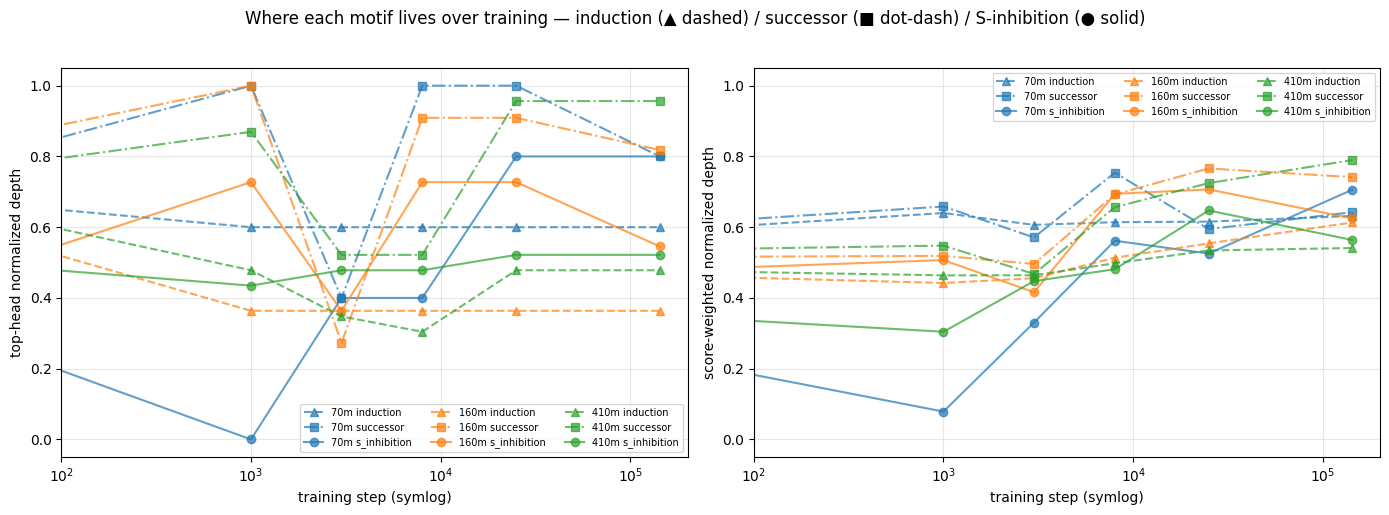


Final-checkpoint normalized depth per motif and size:
  Pythia-70m:
        induction: top-head=0.600  weighted=0.632
        successor: top-head=0.800  weighted=0.642
     s_inhibition: top-head=0.800  weighted=0.706
  Pythia-160m:
        induction: top-head=0.364  weighted=0.613
        successor: top-head=0.818  weighted=0.742
     s_inhibition: top-head=0.545  weighted=0.625
  Pythia-410m:
        induction: top-head=0.478  weighted=0.541
        successor: top-head=0.957  weighted=0.790
     s_inhibition: top-head=0.522  weighted=0.564


In [8]:
def top_head_per_cell(df_in, motif_label, score_col='score'):
    out = []
    for (size, step), grp in df_in.groupby(['size', 'step']):
        if grp.empty:
            continue
        idx = int(np.argmax(grp[score_col].values))
        row = grp.iloc[idx]
        n_layers = int(grp['layer'].max() + 1)
        out.append(dict(
            size=size, step=step, motif=motif_label,
            layer=int(row['layer']), head=int(row['head']),
            score=float(row[score_col]),
            n_layers=n_layers,
            normalized_depth=float(row['layer']) / max(n_layers - 1, 1),
        ))
    return pd.DataFrame(out)

def weighted_depth_per_cell(df_in, motif_label, score_col='score'):
    out = []
    for (size, step), grp in df_in.groupby(['size', 'step']):
        if grp.empty:
            continue
        scores = grp[score_col].values.astype(float)
        layers = grp['layer'].values.astype(float)
        weights = np.clip(scores, 0.0, None)
        wsum = float(weights.sum())
        n_layers = int(grp['layer'].max() + 1)
        if wsum <= 0:
            wd = np.nan
        else:
            wl = float((weights * layers).sum() / wsum)
            wd = wl / max(n_layers - 1, 1)
        out.append(dict(size=size, step=step, motif=motif_label, weighted_norm_depth=wd))
    return pd.DataFrame(out)

frames_top = [top_head_per_cell(df, 'successor')]
frames_w = [weighted_depth_per_cell(df, 'successor')]
if ind_path.exists():
    frames_top.append(top_head_per_cell(df_ind, 'induction'))
    frames_w.append(weighted_depth_per_cell(df_ind, 'induction'))
if si_path.exists():
    frames_top.append(top_head_per_cell(df_si, 's_inhibition'))
    frames_w.append(weighted_depth_per_cell(df_si, 's_inhibition'))
top_df = pd.concat(frames_top, ignore_index=True)
w_df = pd.concat(frames_w, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, source_df, ycol, ylabel in zip(
    axes,
    [top_df, w_df],
    ['normalized_depth', 'weighted_norm_depth'],
    ['top-head normalized depth', 'score-weighted normalized depth'],
):
    for size in SIZES:
        for motif in ['induction', 'successor', 's_inhibition']:
            sub = source_df[(source_df['size'] == size) & (source_df['motif'] == motif)]
            if sub.empty or sub[ycol].isna().all():
                continue
            sub = sub.sort_values('step')
            ax.plot(sub['step'], sub[ycol],
                    marker=MOTIF_MARKER[motif],
                    linestyle=MOTIF_LINESTYLE[motif],
                    color=SIZE_COLOR[size],
                    label=f'{size} {motif}', alpha=0.7)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(100, 200000)
    ax.set_xlabel('training step (symlog)')
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='best', ncol=3)
fig.suptitle('Where each motif lives over training — induction (▲ dashed) / successor (■ dot-dash) / S-inhibition (● solid)', y=1.02)
plt.tight_layout()
plt.show()

print('\nFinal-checkpoint normalized depth per motif and size:')
for size in SIZES:
    print(f'  Pythia-{size}:')
    for motif in ['induction', 'successor', 's_inhibition']:
        rec = top_df[(top_df['size'] == size) & (top_df['motif'] == motif) & (top_df['step'] == 143000)]
        rec_w = w_df[(w_df['size'] == size) & (w_df['motif'] == motif) & (w_df['step'] == 143000)]
        if rec.empty:
            continue
        top_d = float(rec['normalized_depth'].iloc[0])
        w_d = float(rec_w['weighted_norm_depth'].iloc[0]) if not rec_w.empty else float('nan')
        print(f'    {motif:>13s}: top-head={top_d:.3f}  weighted={w_d:.3f}')

## Verdict

Phase 1.4 deliverable (iii) status: complete pending re-execution. Specific findings depend on the data; populate this section after the sweep + re-execution.

Key questions answered:

1. **Successor-head emergence in each Pythia size by step143000?** Per the anchor result for Pythia-410M (deliverable ii), L22H6 clears τ_lift with cross-category breadth. The 18-cell sweep characterizes the count and emergence trajectory across all three sizes.

2. **First-emergence step ordering?** The H1-C registered hypothesis predicts induction → successor → S-inhibition. The first-emergence-step table above tests this directly, per Pythia size.

3. **Layer depth ordering?** H1-C's compositional account predicts deeper layers along the chain. Both top-head and score-weighted-depth views are reported.

4. **70m successor heads marginal?** The brief's risk note anticipated this. The 70m row of the per-cell summary above documents whatever the data shows; if 70m never crosses τ_lift in the preview grid, that's the post-hoc decision point for dropping 70m from the H1-C ordering test.

**Phase 1 (Tooling & Replication) is now complete pending Phase 1.4 close-out commit.** All three motifs (induction, S-inhibition, successor) have been validated on GPT-2 small, anchor-checked on Pythia-410M, and swept across the 18-cell exploration grid. Phase 2's full multi-motif sweep (40 checkpoints × 3 sizes × 3 motifs with bootstrap CIs) inherits the locked detector, threshold, and prompt-set protocols from this phase.